# Fund Workstation

## Pre-Analysis Loading

#### Environment Setting

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds, rerun_no_perf_files, continue_running

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT CHINA','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['EUREKAHEDGE WORLD', 'MSCI CHINA',	'MSCI WORLD', 'EUREKAHEDGE ASIA', 'TOPIX', 'S&P 500', 'SOX', 'KOSPI', 'TAIEX', 'MSCI EM', 'RUSSELL 2000', 'STOXX 600', 'STOXX 50', 'FTSE UK', 'US HEALTHCARE', 'US FINANCIAL', 'US ENERGY', 'COMMODITY']

#### Load Data via .json

In [45]:
test = load_saved_json(folder_path=r"input\forest avenue")
marex = init_funds(test)


In [16]:
port = load_saved_json(folder_path=r"input\individual investigation")
statar = init_funds(port)


#### Load Data via .csv

In [21]:
# Use for manually update csv data of our portfolio and indices and merge with json file
portfolio_csv = input_monthly_returns(r"RETURN DATA.csv")

In [24]:
# Use for manually input unparsable pdf data and merge with json file 
manual_csv = input_monthly_returns(r"MANUAL INPUTS.csv")
funds = merge_funds(portfolio_csv, manual_csv)

#### GPT Input Factsheet

##### Parse Everything

In [ ]:
# Do not open the pdf while running, or the renaming process will encounter error
gpt_fund = process_pdfs_in_folder(folder_path=r"input\individual investigation",save=True)
forest_avenue = init_funds(gpt_fund)

Processing: input\forest avenue\Forest Avenue Capital Monthly Performance Report September 2025 - River Delta.pdf
No valid year found in ['Standard Tranche', '6.10%', '-3.98%', '-7.92%', '6.57%', '6.85%', '8.53%', '-1.30%', '-0.55%', '1.63%', '', '', '', '15.64%', '114.38%'], appending 2025
No valid year found in ['Founders Tranche D', '6.29%', '-4.46%', '-7.63%', '6.57%', '7.06%', '8.78%', '-1.32%', '-0.53%', '6.30%', '-4.45%', '-7.60%', '6.59%', '16.37%', '128.24%'], appending 2024
No valid year found in ['Founders Tranche C', '6.40%', '-4.54%', '-7.65%', '6.57%', '7.19%', '8.93%', '-1.34%', '-0.56%', '1.72%', '', '', '', '16.48%', '129.70%'], appending 2023
No valid year found in ['Founders Tranche B', '8.95%', '-1.32%', '-0.54%', '1.74%', '', '', '', '16.67%', '131.21%', '', '', '', '', ''], appending 2022
No valid year found in ['Founders Tranche A', '6.42%', '-4.52%', '-7.63%', '6.59%', '7.20%', '', '', '', '', '', '', '', '', ''], appending 2021
Non-number found in FOREST's earl

##### Continue Running Unparsed

In [29]:
gpt_fund_2 = continue_running(folder_path=r"input\marex",save=True)
gpt_fund_2 = init_funds(gpt_fund_2)

Processing: input\marex\presentation - 2025- Dec.pdf
No valid year found in ['Gross', '0.073', '0.046', '-0.099', '-0.045', '0.186', '0.089', '0.04', '0.017', '0.143', '0.051', '0.002', '', '0.588', '1.966'], appending 2025
No valid year found in ['Net', '0.061', '0.038', '-0.087', '-0.045', '0.163', '0.076', '0.034', '0.014', '0.125', '0.044', '0.001', '', '0.484', '1.548'], appending 2024
No valid year found in ['MSCI ACWI USD', '0.034', '-0.006', '-0.04', '0.009', '0.057', '0.045', '0.014', '0.025', '0.036', '0.022', '-0.001', '', '0.21', '0.489'], appending 2023
No valid year found in ['HFRI Equity Hedge Index', '0.017', '-0.01', '-0.022', '0.004', '0.037', '0.034', '0.025', '0.033', '0.026', '0.014', '', '', '0.167', '0.365'], appending 2022
No valid year found in ['Gross', '-0.02', '0.115', '0.021', '0.023', '0.072', '0.026', '-0.065', '-0.027', '0.178', '0.016', '0.29', '-0.084', '0.618', '0.868'], appending 2021
No valid year found in ['Net', '-0.018', '0.099', '0.018', '0.02',

In [ ]:
gpt_fund = gpt_fund_2 | gpt_fund

##### Re-Run No Performance Funds

In [35]:
# Target the files with "No Performance Found", and re-run the analysis again
rerun_no_perf_files(folder_path=r"input\marex",save=True)

Re-processing (no performance before): input\marex\ASPEN GLOBAL_parsed from_presentation - 2025- Dec.pdf
No valid year found in ['Gross', '0.073', '0.046', '-0.099', '-0.045', '0.186', '0.089', '0.04', '0.017', '0.143', '0.051', '0.002', '', '0.588', '1.966'], appending 2025
No valid year found in ['Net', '0.061', '0.038', '-0.087', '-0.045', '0.163', '0.076', '0.034', '0.014', '0.125', '0.044', '0.001', '', '0.484', '1.548'], appending 2024
No valid year found in ['MSCI ACWI USD', '0.034', '-0.006', '-0.04', '0.009', '0.057', '0.045', '0.014', '0.025', '0.036', '0.022', '-0.001', '', '0.21', '0.489'], appending 2023
No valid year found in ['HFRI Equity Hedge Index', '0.017', '-0.01', '-0.022', '0.004', '0.037', '0.034', '0.025', '0.033', '0.026', '0.014', '', '', '0.167', '0.365'], appending 2022
No valid year found in ['Gross', '-0.02', '0.115', '0.021', '0.023', '0.072', '0.026', '-0.065', '-0.027', '0.178', '0.016', '0.29', '-0.084', '0.618', '0.868'], appending 2021
No valid year 

[{'fund_name': 'ASPEN GLOBAL',
  'fund_des': 'ASPEN GLOBAL is a long-term oriented, long-biased global public equities fund focusing on multi-sector investments including industrials, consumer, financials, TMT, and energy. The fund leverages Asia insights and alternative data for differentiated research and employs a valuation-centric, cross-industry, and cross-regional risk management approach. Managed by CIO Damon Meng, the fund aims to grow capital over multi-year cycles while managing downside risk. The fund has demonstrated strong historical gross and net returns with a disciplined investment framework. Rating: 4, overall positive view.',
  'performance': [],
  'investment_location': ['apac', 'north_america', 'europe'],
  'investment_strategy': ['equity_ls'],
  'investment_sector': ['equity_industrials',
   'equity_consumer',
   'equity_finance',
   'equity_TMT',
   'equity_energy'],
  'manager_names': ['Damon Meng', 'Sophie Shea', 'Yutong Xie'],
  'manager_profiles': {'Damon Meng

#### Merging Different Input

In [ ]:
# Use the left hand's PERFORMANCE TABLE to update the right hand one
funds = merge_funds(portfolio_csv, funds)

In [46]:
# Right-hand side has higher priority
funds = funds | marex

#### Save the Changes to .json & .csv

In [ ]:
# Careful what fund you are saving to what folder
save_changes_in_fund(funds, folder_path=r"input\worth_a_look")

In [ ]:
print(funds['ASIAN TECHNOLOGY'].total_max_dd)

## Fund Analysis

#### Dataframe Comparison

In [40]:
df = compare_funds(funds)
do_not_display = our_index + our_portfolio
df = df[~df["Name"].isin(do_not_display)].reset_index(drop=True)
print(df)


                   Name                                        Description  \
0                   ARB  Melanion Arb Fund specializes in dividend futu...   
1           BLUE RIBAND  Blue Riband Fund LP is a concentrated, high-co...   
2             HYPERNOVA  The Io Hypernova Fund is an inflation/macro tr...   
3                 MEDIT  MEDIT is a generalist long/short hedge fund fo...   
4               ORGUEIL  ORGUEIL is a global equity fund focusing on op...   
5            PROMERITUM  ProMeritum EM Segregated Portfolio is a macro ...   
6                 SHARC  SHARC is a long-short commodity futures fund u...   
7              SHIPROCK  SHIPROCK is a London-based global distressed a...   
8                 TOSCA  Tosca Focus aims for superior total return thr...   
9                  TSCI  TSCI is a monthly liquidity fund investing in ...   
10                RDGFF                                               None   
11  ALPHA OPPORTUNITIES  ALPHA OPPORTUNITIES is a multi-strategy

In [ ]:
# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM (in Mn USD)", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", "Month Running",
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]


In [8]:
# sort by what we think important   
df = df.sort_values(by=["Sharpe Ratio", "Annualized Return"], ascending=[False, False])
# mask and filtered only the wanted funds
mask =  (df["Month Running"] > 6) & (df["Annualized Return"] > 0.12)
df['Worth a Look'] = mask
# Display only the following columns
display_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Description","Max Drawdown" ]]
display_df


,Worth a Look,Name,Sharpe Ratio,Annualized Return,AUM (in Mn USD),Month Running,Description,Max Drawdown
8,True,TOSCA,3.024070,0.129571,0.00,192.766667,Tosca Focus aims for superior total return thr...,0.015515
7,True,SHIPROCK,2.492663,0.236850,1050.00,31.433333,SHIPROCK is a London-based global distressed a...,0.087378
5,True,PROMERITUM,2.250194,0.158477,200.00,19.300000,ProMeritum EM Enhanced Feeder Fund is a macro ...,0.059256
4,True,ORGUEIL,1.877879,0.418127,83.97,15.200000,ORGUEIL is a global equity fund focusing on op...,0.098517
3,True,MEDIT,1.763269,0.182703,105.00,28.466667,MEDIT is a generalist long/short hedge fund fo...,0.085672
10,True,RDGFF,1.495019,0.152524,NaN,93.333333,None,0.078768
6,True,SHARC,1.439767,0.213001,84.00,40.600000,SHARC is a long-short commodity futures fund u...,0.128376
0,True,ARB,1.288698,0.458938,13.20,63.933333,Melanion Arb Fund specializes in dividend futu...,0.465977
2,True,HYPERNOVA,1.132762,0.159586,350.00,54.733333,The Io Hypernova Fund is an inflation/macro tr...,0.148637
1,True,BLUE RIBAND,0.914634,0.296369,0.00,90.333333,"Blue Riband Fund LP is a concentrated, high-co...",0.470680


#### Save it to CSV

In [25]:
# Select the column you want to save
output_df = df[["Worth a Look","Name", "Sharpe Ratio", "Annualized Return", "AUM (in Mn USD)", "Month Running","Max Drawdown" ,"Net Exposure","Strategy", "Sector","Contact","Description", "Mgmt Fee", "Perf Fee"]]
output_df.to_csv("output/funds_comparison.csv", index=False)

#### Save it to a list

In [ ]:
exclude_list = our_index + our_portfolio
df = df[~df["Name"].isin(exclude_list)].reset_index(drop=True)
worth_looking = df.loc[df["Worth a Look"], "Name"].tolist()
print(worth_looking)

#### Compare Performance Table

In [ ]:
funds['ONELS'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)

#### Plot Cumulative Return

In [11]:

funds_to_be_plot = subset_of_funds(funds, ['QUANTICA', 'RDGFF', 'US FINANCIAL'])
start_month = "2000-12"
end_month = "2025-9"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=False,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


#### Correlation Heat Map

In [ ]:
# Correlation heatmap

start_month = "2019-12"
end_month = "2025-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

#### Efficient Frontier Analysis

In [23]:
remove_list = ['RDGFF', 'E20']

for i, k in enumerate(our_portfolio):
    if k in remove_list:
        our_portfolio.pop(i)
test =  ['RDGFF', 'QUANTICA']
print(our_portfolio)


funds_to_be_plot = subset_of_funds(funds, test)
print(len(funds))

['TAIREN', 'HAO', 'LEXINGTON', 'LIM', 'FOREST', 'WT CHINA', '3W GLOBAL', '3W CHINA', '3W HEALTHCARE', 'TIMEFOLIO', 'MONOLITH', 'PERSEVERANCE', 'NEO IVY', 'JH BIOTECH', 'QUANTICA']
35


In [24]:
# Choose Mode between "Maximum Sharpe", "Minimum Variance", "Target Return"
fig, weights, stats = minimum_variance_analysis(funds=funds_to_be_plot, mode="Maximum Sharpe", title=None)
print(weights)
print(stats)

Expected annual return: 13.5%
Annual volatility: 74.9%
Sharpe Ratio: 0.18


OrderedDict({'RDGFF': 0.5969182857139664, 'QUANTICA': 0.4030817142860337})
{'n_months': 93, 'Volatility': np.float64(0.7492220065039944), 'Expected Return': np.float64(0.13535064272579878), 'Sharpe': np.float64(0.18065492143960024)}


#### Summary of a Fund

In [44]:
# for f in ['DC', 'PROTIUM OPPORTUNITIES', 'FORWARDEDGE', 'ALPHA OPPORTUNITIES', 'ASIA ABSOLUTE', 'REGAL TACTICAL', 'PANVIEW', 'DKAM GLOBAL', 'AURIGIN', 'RDGFF', 'DUNAMIS', 'FRONTIER', 'HEL VED']:
fund_name = 'FOREST STD'
funds[fund_name].summary_of_a_fund(benchmark_fund=funds['MSCI WORLD'],language="en",save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Performance during our fund's top 10 drawdowns", n_worst=10,  save=True)
funds[fund_name].compare_worst_performance(funds['RDGFF'], title="Entire performance compared with our fund's" ,n_worst=100,  save=True)

KeyError: 'FOREST STD'

#### Correlation Deep Dive

In [ ]:
fund_name = 'FOREST STD'
funds_to_be_plot = subset_of_funds(funds, [fund_name] + our_index)
fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12, save=True)
fig.show()

AttributeError: 'NoneType' object has no attribute 'monthly_returns'

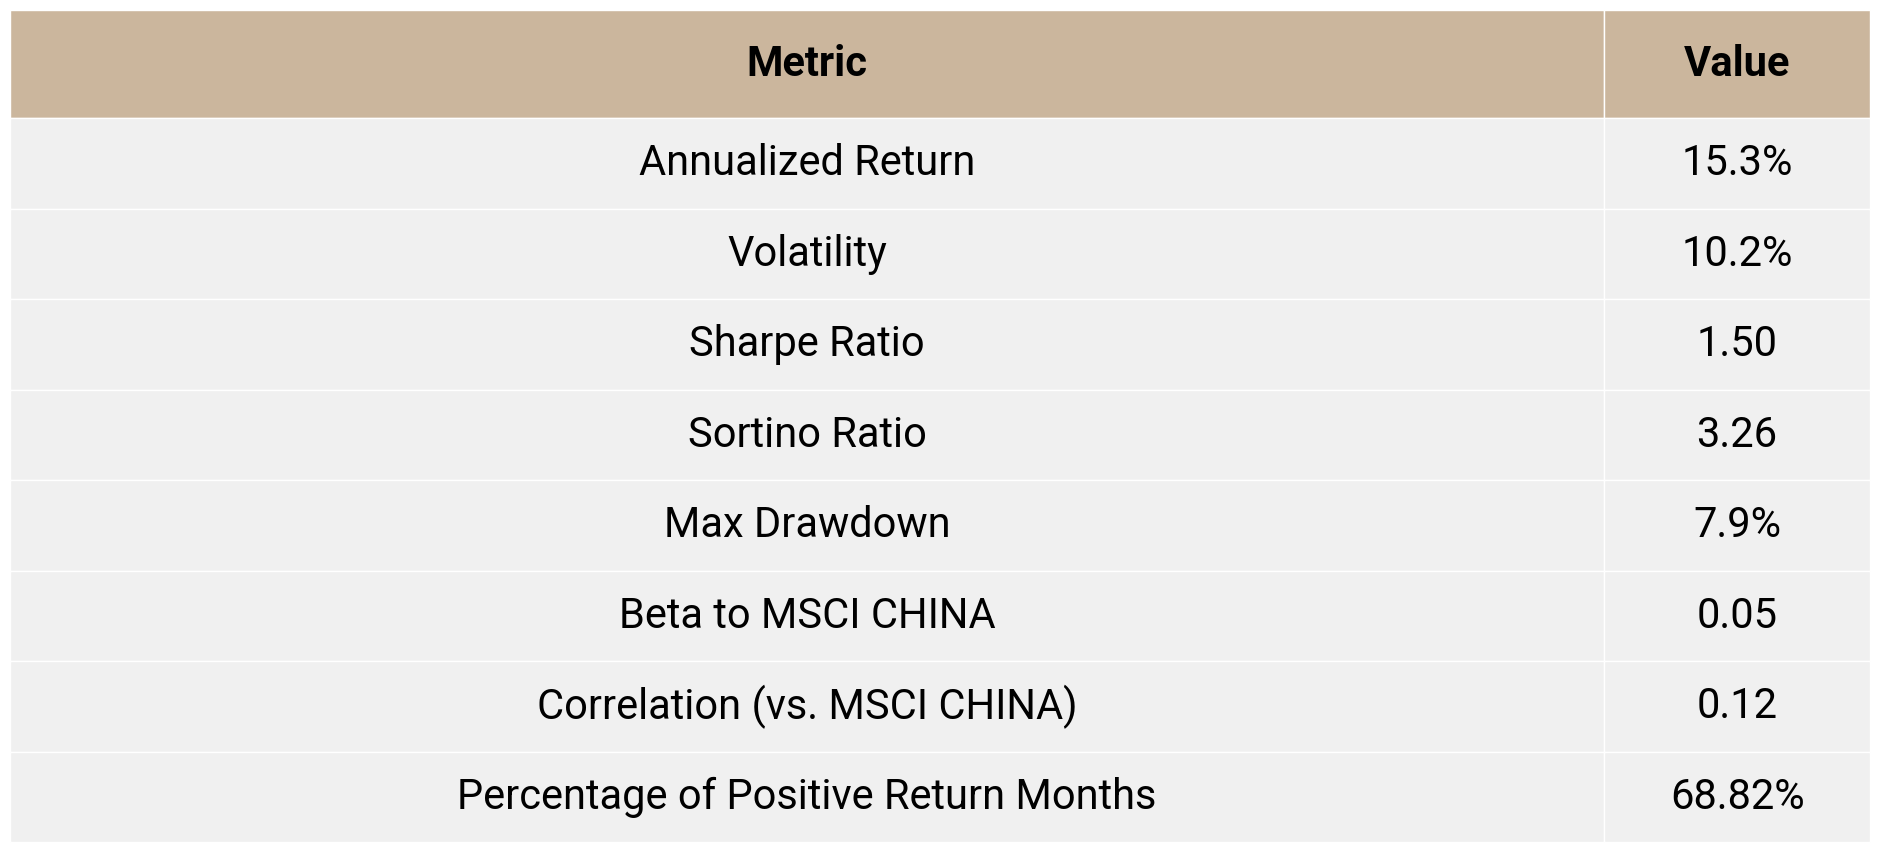

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]



fig1 = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )

fig2 = compa